# A/B Testing Analysis for Website Conversion

## Comparing Old Page vs New Page Performance

**Author:** Rishabh Perewar  
**Tools Used:** Python, Pandas, Matplotlib, SciPy, Jupyter Notebook  
**Project Type:** Product Analytics / A/B Testing / Conversion Analysis

## Project Objective
The purpose of this project is to evaluate whether a new website landing page improves customer conversion compared to the old landing page.

This notebook follows a structured A/B testing workflow:
- inspect the dataset
- clean invalid experiment records
- compare conversion rates
- visualize results
- perform statistical testing
- make a final business recommendation

## Business Question
Should the company replace the old landing page with the new landing page based on conversion performance?

## Dataset Overview

The dataset contains user-level experiment data from an A/B test.

### Columns used in this analysis
- **user_id**: unique identifier for each user
- **timestamp**: time of observation
- **group**: experiment group (`control` or `treatment`)
- **landing_page**: page shown to the user (`old_page` or `new_page`)
- **converted**: whether the user converted (`1`) or not (`0`)

### Experiment setup
- **Control group** saw the **old page**
- **Treatment group** saw the **new page**

The goal is to determine whether the new page led to a statistically significant improvement in conversions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import chi2_contingency

## Step 1: Load the Dataset

In this step, the dataset is loaded into Python using Pandas.  
We first inspect the first few rows to confirm that the file was imported correctly.

In [2]:
df = pd.read_csv(r"C:\Users\rpere\Downloads\ab_data.csv")

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## Step 2: Initial Data Inspection

Before performing any analysis, it is important to understand:
- how many rows are present
- whether there are missing values
- whether the experiment groups are balanced
- whether the page assignments are logical

This step helps us confirm that the dataset is suitable for analysis.

In [16]:
print("Shape of dataset:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nGroup counts:")
print(df['group'].value_counts())

print("\nLanding page counts:")
print(df['landing_page'].value_counts())

print("\nConversion counts:")
print(df['converted'].value_counts())

Shape of dataset: (294478, 5)

Missing values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Duplicate rows: 0

Group counts:
group
treatment    147276
control      147202
Name: count, dtype: int64

Landing page counts:
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

Conversion counts:
converted
0    259241
1     35237
Name: count, dtype: int64


## Inference from Initial Data Inspection

The dataset contains **294,478 observations** and **5 variables**, representing user interactions during an A/B testing experiment.

### Missing Values
No missing values were found in any column. This means the dataset is complete and suitable for analysis without requiring imputation or additional preprocessing.

### Duplicate Records
No duplicate rows were detected, indicating that each observation represents a unique event in the experiment.

### Group Distribution
The experiment groups are almost perfectly balanced:

- **Treatment group:** 147,276 users  
- **Control group:** 147,202 users  

Balanced group sizes are important in A/B testing because they reduce bias and allow fair comparison between experiment variants.

### Landing Page Distribution
The dataset shows equal exposure to both landing pages:

- **Old page:** 147,239 users  
- **New page:** 147,239 users  

This indicates that traffic allocation between the two variants was evenly distributed.

### Conversion Distribution
The dataset records:

- **35,237 successful conversions**
- **259,241 non-conversions**

This means the overall baseline conversion rate is approximately **11.97%**, which is typical for many online product experiments.

### Key Observation
At this stage, the dataset appears clean and well-balanced. However, before performing any statistical analysis, we must verify that:

- Users in the **control group saw only the old page**
- Users in the **treatment group saw only the new page**

If mismatches exist, they must be removed to maintain the validity of the experiment.

## Step 3: Cleaning Experiment Assignments

In a properly designed A/B test:

- The **control group** should only see the **old page**
- The **treatment group** should only see the **new page**

However, real-world experiment data may contain assignment mismatches due to logging errors or experiment implementation issues.

To ensure accurate results, we remove all records where:

- Control users were shown the new page
- Treatment users were shown the old page

We also remove duplicate users so that each user contributes only one observation to the experiment.

In [17]:

df_clean = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
].copy()

print("Shape after removing mismatched records:", df_clean.shape)

# Remove duplicate users
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')

print("Shape after removing duplicate users:", df_clean.shape)

Shape after removing mismatched records: (290585, 5)
Shape after removing duplicate users: (290584, 5)


## Inference

After cleaning, the dataset now contains only valid experiment records.

This step is extremely important because mismatched assignments can bias the results and lead to incorrect conclusions.

By keeping only correct page-group combinations and removing duplicate users, the analysis becomes more reliable and closer to real-world experimentation standards.

## Step 4: Conversion Rate Summary

Now we calculate the core performance metrics for each group:
- number of users
- number of conversions
- conversion rate

This gives us the first direct comparison between the old page and the new page.

In [19]:
summary = df_clean.groupby('group').agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

summary['conversion_rate_pct'] = (summary['conversion_rate'] * 100).round(2)
summary

,group,users,conversions,conversion_rate,conversion_rate_pct
0,control,145274,17489,0.120386,12.04
1,treatment,145310,17264,0.118808,11.88


## Inference

The conversion summary shows that:

- **Control group conversion rate = 12.04%**
- **Treatment group conversion rate = 11.88%**

This means the **old page performed slightly better** than the new page in this experiment.

Although the difference is small, the treatment page does **not** appear to improve conversions based on the raw conversion rates alone.

To confirm whether this difference is statistically meaningful, we now perform formal hypothesis testing.

## Step 5: Visual Comparison of Conversion Rates

A bar chart helps compare the conversion rates of the control and treatment groups more clearly.

This makes it easier to visually understand whether one page appears to outperform the other.

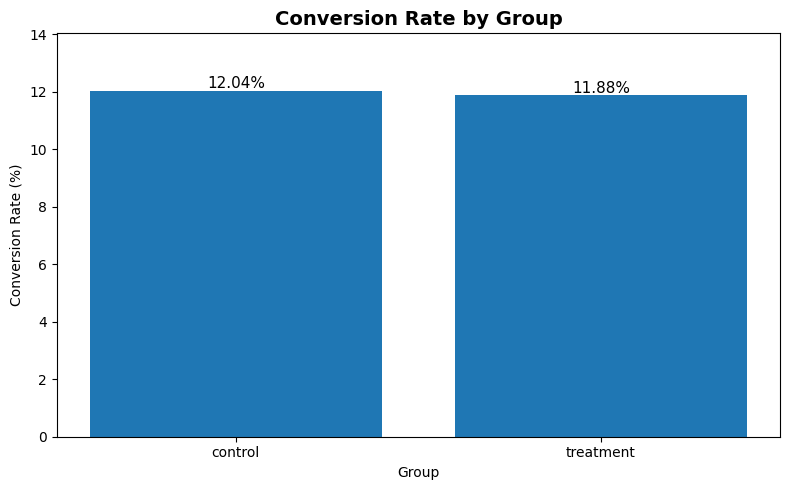

In [20]:
plt.figure(figsize=(8,5))
bars = plt.bar(summary['group'], summary['conversion_rate_pct'])

plt.title("Conversion Rate by Group", fontsize=14, weight='bold')
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Group")

for bar, value in zip(bars, summary['conversion_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{value:.2f}%", ha='center', fontsize=11)

plt.ylim(0, max(summary['conversion_rate_pct']) + 2)
plt.tight_layout()
plt.savefig("conversion_rates.png", dpi=200)
plt.show()

## Inference

The chart confirms that the **control group has a slightly higher conversion rate** than the treatment group.

Visually, the two bars are very close to each other, which suggests that the difference may not be large enough to be statistically significant.

A formal statistical test is required before making a business decision.

## Step 6: Hypothesis Testing

To determine whether the difference in conversion rates is statistically significant, we perform a **two-proportion z-test**.

### Hypotheses

- **Null Hypothesis (H0):** The conversion rate of the new page is equal to the conversion rate of the old page.
- **Alternative Hypothesis (H1):** The conversion rate of the new page is different from the conversion rate of the old page.

### Decision Rule
- If **p-value < 0.05**, we reject the null hypothesis.
- If **p-value > 0.05**, we fail to reject the null hypothesis.

In [22]:
control = df_clean[df_clean['group'] == 'control']['converted']
treatment = df_clean[df_clean['group'] == 'treatment']['converted']

n1 = control.shape[0]
n2 = treatment.shape[0]

x1 = control.sum()
x2 = treatment.sum()

p1 = x1/n1
p2 = x2/n2

p_pool = (x1 + x2)/(n1 + n2)

se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))

z = (p2 - p1)/se

p_value = 2*(1 - norm.cdf(abs(z)))

print("Control Conversion:", p1)
print("Treatment Conversion:", p2)
print("Z Score:", z)
print("P Value:", p_value)

Control Conversion: 0.1203863045004612
Treatment Conversion: 0.11880806551510564
Z Score: -1.3109241984234394
P Value: 0.18988337448195103


## Inference

The statistical test produced a **p-value of 0.1899**.

Since this value is **greater than 0.05**, we **fail to reject the null hypothesis**.

This means there is **no statistically significant evidence** that the new page performs differently from the old page.

Even though the observed conversion rates are slightly different, that difference is not strong enough to conclude that the new landing page improves performance.

## Step 7: Chi-Square Test for Validation

As an additional validation step, we perform a **chi-square test of independence**.

This helps confirm whether there is a significant relationship between:
- experiment group
- conversion outcome

Using a second statistical method makes the analysis more robust.

In [23]:
contingency = pd.crosstab(df_clean['group'], df_clean['converted'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Contingency Table:\n")
print(contingency)
print("\nChi-square statistic:", round(chi2, 6))
print("P-value:", round(p, 6))

Contingency Table:

converted       0      1
group                   
control    127785  17489
treatment  128046  17264

Chi-square statistic: 1.703566
P-value: 0.191822


## Inference from Chi-Square Test

The chi-square test was conducted to determine whether there is a statistically significant relationship between the **experiment group (control vs treatment)** and the **conversion outcome (converted vs not converted)**.

### Contingency Table Interpretation

| Group | Not Converted | Converted |
|------|---------------|-----------|
| Control | 127,785 | 17,489 |
| Treatment | 128,046 | 17,264 |

From the contingency table, the control group produced **slightly more conversions** than the treatment group. However, the difference between the two groups is relatively small.

### Statistical Results

- **Chi-square statistic:** 1.703566  
- **p-value:** 0.191822  

### Decision Rule

If **p-value < 0.05**, we reject the null hypothesis and conclude that conversion depends on the experiment group.

If **p-value > 0.05**, we fail to reject the null hypothesis.

### Conclusion

Since the **p-value (0.1918) is greater than 0.05**, we fail to reject the null hypothesis.

This means there is **no statistically significant relationship** between the landing page version and the conversion outcome.

### Final Interpretation

The new landing page **does not significantly improve conversion performance compared to the old landing page**.

Even though the control group shows a slightly higher conversion rate, the difference is **not statistically meaningful**, and it could have occurred due to random variation in the experiment.

Therefore, based on the statistical evidence, there is **no strong justification to replace the old landing page with the new one at this time**.

# Final Conclusion

The A/B testing analysis compared the performance of the old landing page and the new landing page using conversion data from a large user sample.

### Final Results
- **Control conversion rate:** 12.04%
- **Treatment conversion rate:** 11.88%
- **Z-test p-value:** 0.1899
- **Chi-square p-value:** 0.1918

### Final Interpretation
The old landing page achieved a slightly higher conversion rate than the new landing page. However, the difference between the two groups is **not statistically significant**.

### Business Decision
Based on this analysis, the company should **not replace the old landing page with the new page** at this time.

The data does not provide enough evidence to show that the new page improves conversion performance.

## Business Recommendation

Based on the results of this A/B test, the company should keep the current landing page for now.

### Recommended next steps
1. Do not launch the new page as a full replacement yet.
2. Review the new page design to identify possible usability or messaging issues.
3. Run a revised A/B test with a stronger page redesign.
4. Consider testing specific changes such as:
   - headline wording
   - call-to-action button text
   - layout simplicity
   - trust signals
   - pricing presentation

A/B testing should continue as an iterative optimization process rather than a one-time decision.

## Key Learnings from This Project

This project demonstrates the complete A/B testing workflow:
- understanding experiment structure
- cleaning invalid test records
- calculating conversion metrics
- visualizing group performance
- applying hypothesis testing
- validating results with a second statistical test
- translating statistical output into business decisions

This notebook shows how data analysis can support product and marketing decisions in a practical business setting.

In [24]:
print("Control Conversion:", p1)
print("Treatment Conversion:", p2)
print("Z Score:", z)
print("P Value:", p_value)

Control Conversion: 0.1203863045004612
Treatment Conversion: 0.11880806551510564
Z Score: -1.3109241984234394
P Value: 0.18988337448195103
